# load Detection model #

In [1137]:
import torch
import glob
import os

PATH = '../region_detection/model.pt'
model = torch.load(PATH)
model.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

## Load test Image ##

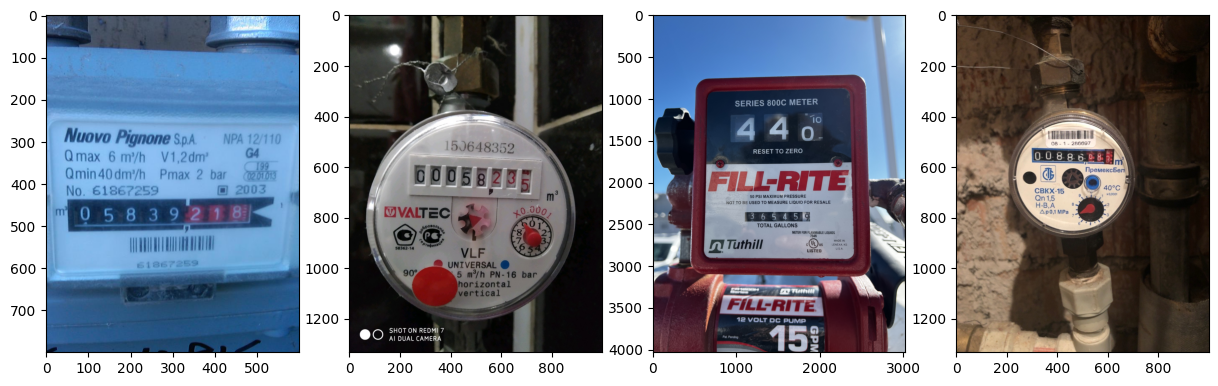

In [1138]:
from PIL import Image
import cv2
import matplotlib.pyplot as plt

imgs = []
for i, file in enumerate(glob.glob('test/*.jpg')):
    img = Image.open(file)
    imgs.append(img)

f, axarr = plt.subplots(1,4, figsize=(15, 5))
figsize=(8, 6)
axarr[0].imshow(imgs[0])
axarr[1].imshow(imgs[1])
axarr[2].imshow(imgs[2])
axarr[3].imshow(imgs[3])
plt.show()

## Region detection ##

In [1139]:
import torchvision.transforms as T

transform = T.ToTensor()
xywh = []
for i, img in enumerate(imgs):

    img = transform(img)
    with torch.no_grad():
        prediction = model([img])

    bboxes, labels, scores = prediction[0]['boxes'], prediction[0]['labels'], prediction[0]['scores']
    index = torch.argmax(scores).item()
    bbox = bboxes[index]
    x,y,w,h = bbox.detach().numpy()
    x,y,w,h = int(x), int(y), int(w), int(h)
    xywh.append([x,y,w,h])

xywh

[[42, 438, 462, 508],
 [264, 587, 710, 700],
 [1073, 2338, 1857, 2489],
 [304, 525, 613, 597]]

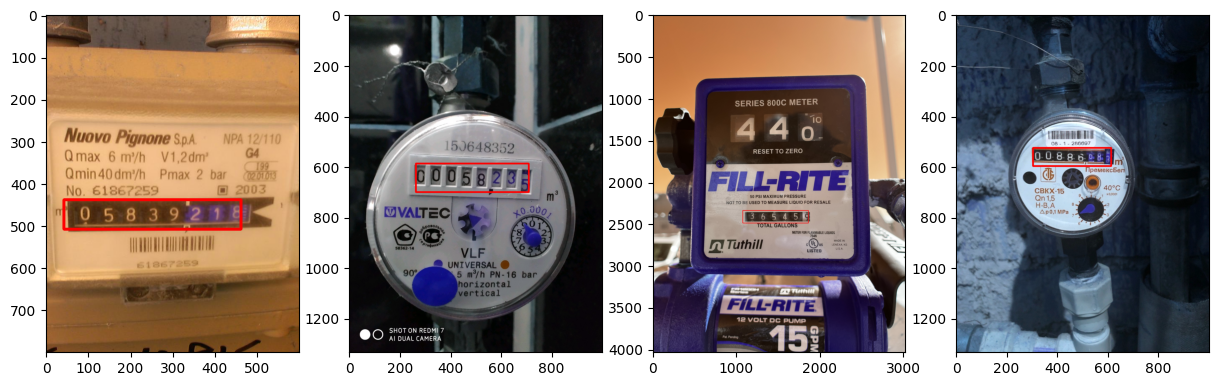

In [1140]:
imgs = []
for i, file in enumerate(glob.glob('test/*.jpg')):
    img = cv2.imread(file)
    imgs.append(img)
    x,y,w,h = xywh[i]
    cv2.rectangle(img, (x, y), (w, h), color = (255, 0, 0), thickness = 5)

f, axarr = plt.subplots(1,4, figsize=(15, 5))
figsize=(8, 6)
axarr[0].imshow(imgs[0])
axarr[1].imshow(imgs[1])
axarr[2].imshow(imgs[2])
axarr[3].imshow(imgs[3])
plt.show()

## image crop ##

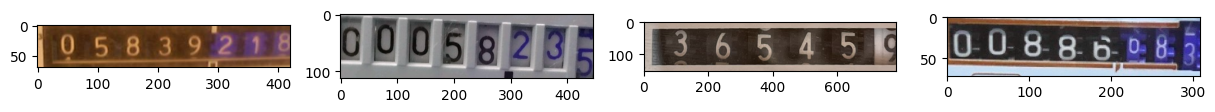

In [1141]:
# img = cv2.imread(path)
# crop_img = img[y:h, x:w]
# plt.imshow(crop_img)
# plt.show()
import copy
xywh_copy = xywh
crop_imgs = []
crop_imgs_copy = []
for i, file in enumerate(glob.glob('test/*.jpg')):
    img = cv2.imread(file)
    x,y,w,h = xywh[i]
    crop_imgs.append(img[y:h, x:w])
    crop_imgs_copy.append(copy.deepcopy(img[y:h, x:w]))

f, axarr = plt.subplots(1,4, figsize=(15, 5))
figsize=(8, 6)
axarr[0].imshow(crop_imgs[0])
axarr[1].imshow(crop_imgs[1])
axarr[2].imshow(crop_imgs[2])
axarr[3].imshow(crop_imgs[3])
plt.show()


## Recognition ##

using a similar model as detection model

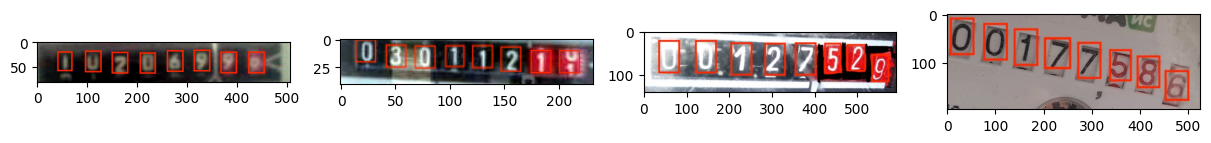

In [1142]:
#train example
imgs = []
for i, file in enumerate(glob.glob('../data/annotation_v2/annotate_boxes/*.jpg')):
    img = Image.open(file)
    imgs.append(img)
    if(i==3):
        break

f, axarr = plt.subplots(1,4, figsize=(15, 5))
figsize=(8, 6)
axarr[0].imshow(imgs[0])
axarr[1].imshow(imgs[1])
axarr[2].imshow(imgs[2])
axarr[3].imshow(imgs[3])
plt.show()

# Load Recognition model #

In [1143]:
model = torch.load('../recognition_model/model.pt')
model.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

# convert crop image to tensor and put into model #

In [1144]:
def label_check(labels):
   # value = ''.join([str(x) for x in labels])
    digits = labels - 1
    value = int(''.join(str(digit) for digit in digits.tolist())) 
    #value = int(value.strip('0'))
    if len(labels) == 8:
        value = float(value/1000)
    elif len(labels) == 7:
        value = float(value/100)
    elif len(labels) == 6:
        value = float(value/10)
    return value

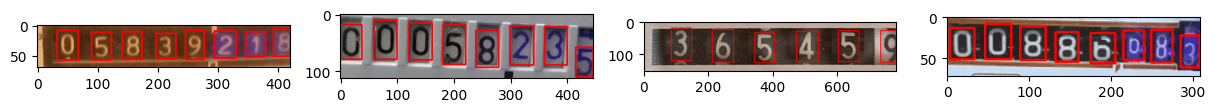

In [1145]:
import torchvision
values = []
file_boxes = []
for i, img in enumerate(crop_imgs):

    img_t = transform(img)
    with torch.no_grad():
        prediction = model([img_t])

    # there will likely be multiple overlapping predictions for the digits. this filters down to
    # only have one digit in each location, and returns them in order from left-to-right
    # print(prediction[0]['scores'][:8])
    #print(prediction[0]['labels'])
    # print(prediction[0]['boxes'][:8])
    filtered_indices = sorted(
        torchvision.ops.nms(prediction[0]['boxes'], prediction[0]['scores'], iou_threshold=0.1).tolist(),
        key=lambda index: prediction[0]['boxes'][index, 0].item()
    )
    #print(filtered_indices)
    prediction[0] = {key: prediction[0][key][filtered_indices] for key in ('boxes', 'labels', 'scores')}

    bboxes, labels, scores= prediction[0]['boxes'], prediction[0]['labels'], prediction[0]['scores']
    # print(labels)
    # print(scores)
    boxes = bboxes.detach().numpy()
    l = labels.detach().numpy()
    xywh = []
    for i in range(len(boxes)):
        x,y,w,h = boxes[i]
        x,y,w,h = int(x), int(y), int(w), int(h)
        xywh.append([x,y,w,h])
        cv2.rectangle(img, (x, y), (w, h), color = (255, 0, 0), thickness = 2)
        #cv2.putText(img, str(l[i]), (x, y+30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2, cv2.LINE_AA)
    file_boxes.append(xywh)
    values.append(label_check(labels))



f, axarr = plt.subplots(1,4, figsize=(15, 5))
figsize=(8, 6)
axarr[0].imshow(crop_imgs[0])
axarr[1].imshow(crop_imgs[1])
axarr[2].imshow(crop_imgs[2])
axarr[3].imshow(crop_imgs[3])

# axarr[0].set_title(values[0])
# axarr[1].set_title(values[1])
# axarr[2].set_title(values[2])
# axarr[3].set_title(values[3])
plt.show()
#file_boxes


# Crop the image base on boxes #

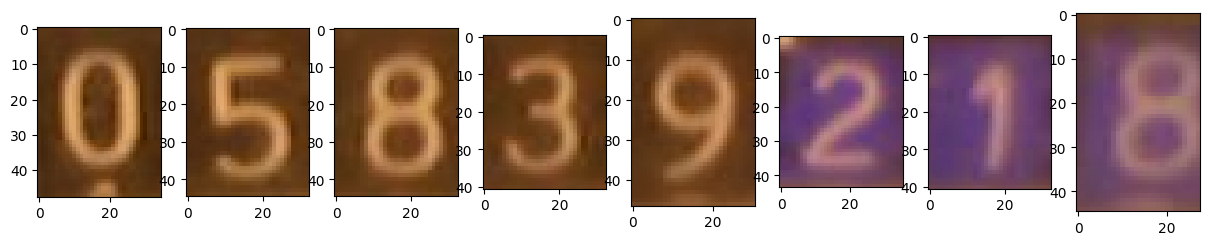

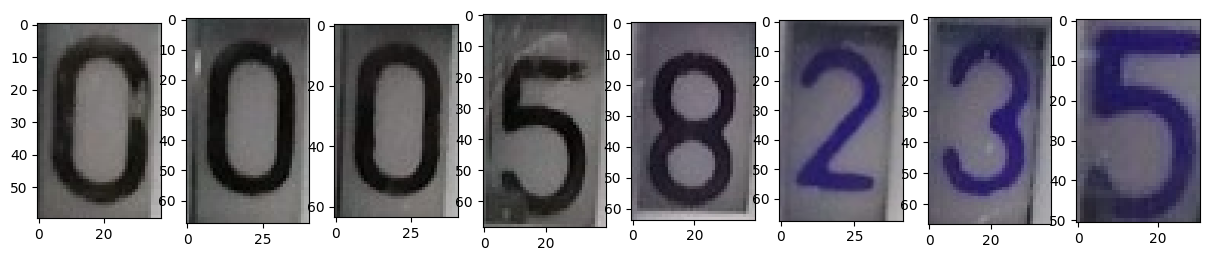

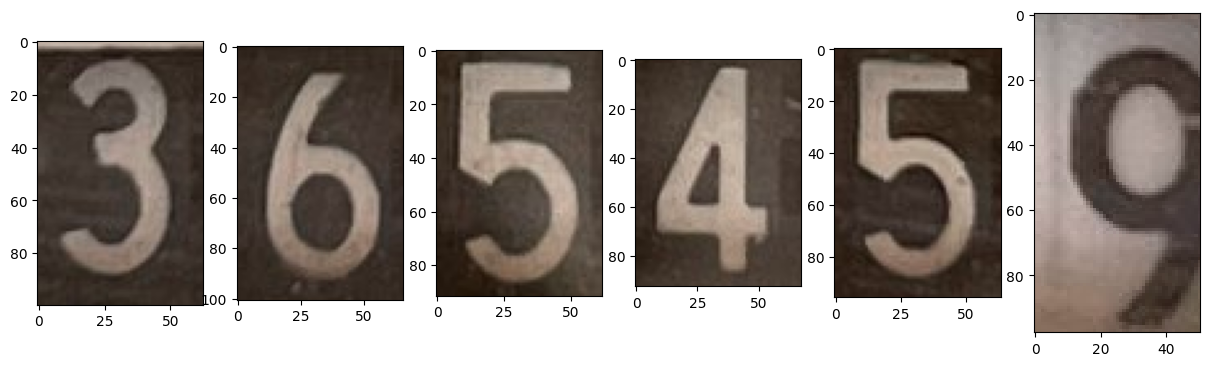

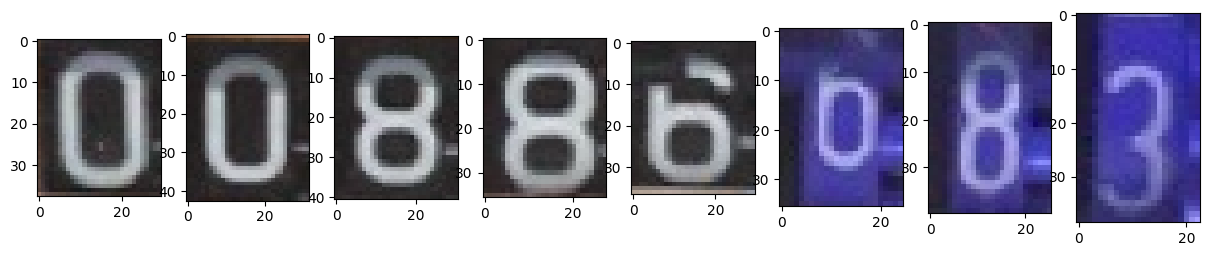

In [1146]:

for z in range(len(file_boxes)):
    boxes = file_boxes[z]
    f, axarr = plt.subplots(1,len(boxes), figsize=(15, 5))
    figsize=(8, 6)
    for i in range(len(boxes)):
        x,y,w,h = boxes[i]
        crop_img = crop_imgs_copy[z][y:h, x:w]
        axarr[i].imshow(crop_img)

# OCR pytesseract #

In [1158]:
import pytesseract
import numpy as np
def ocr(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    rectKernel = cv2.getStructuringElement(cv2.MORPH_RECT, (13, 5))
    t = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, rectKernel)
    sharpen_kernel = np.array([[-1,-1,-1], [-1,9,-1], [-1,-1,-1]])
    sharpen = cv2.filter2D(gray, -1, sharpen_kernel)
    thresh = cv2.threshold(sharpen, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]
    output = pytesseract.image_to_string(gray, lang='eng', config='--psm 6 --oem 3 -c tessedit_char_whitelist=0123456789')
    ret,th1 = cv2.threshold(gray ,100,255,cv2.THRESH_BINARY_INV)
    if(output == ''):
        output = pytesseract.image_to_string(th1, lang='eng', config='--psm 6 --oem 3 -c tessedit_char_whitelist=0123456789')
    if(output == ''):
        output = pytesseract.image_to_string(t, lang='eng', config='--psm 6 --oem 3 -c tessedit_char_whitelist=0123456789')
    if(output == ''):
        output = pytesseract.image_to_string(thresh, lang='eng', config='--psm 6 --oem 3 -c tessedit_char_whitelist=0123456789')
    return output, thresh


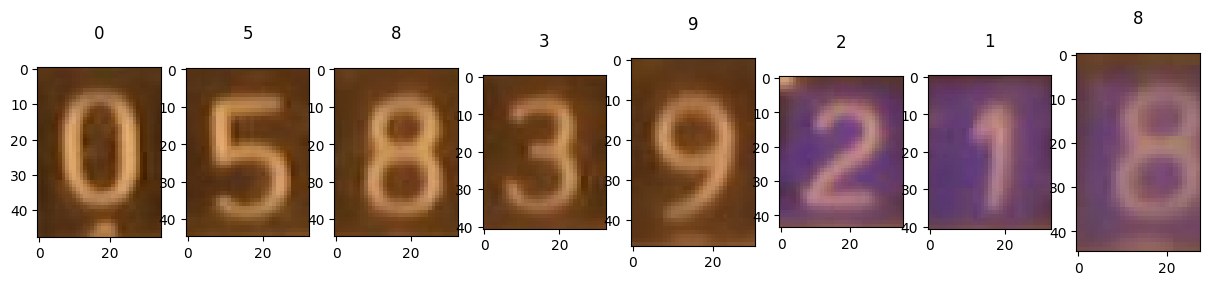

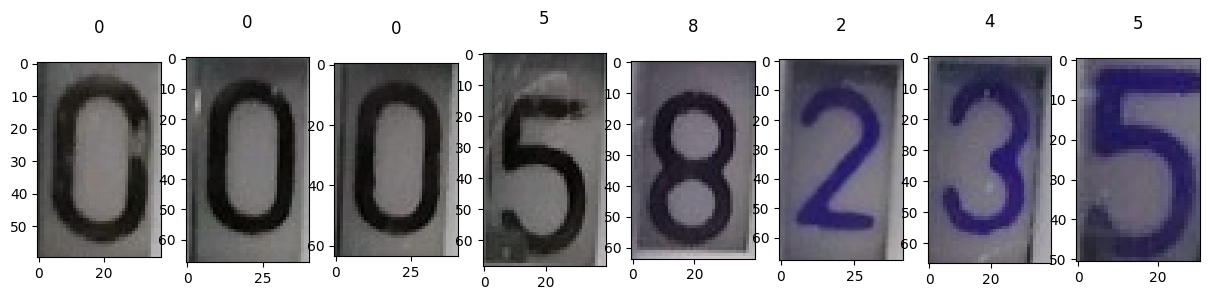

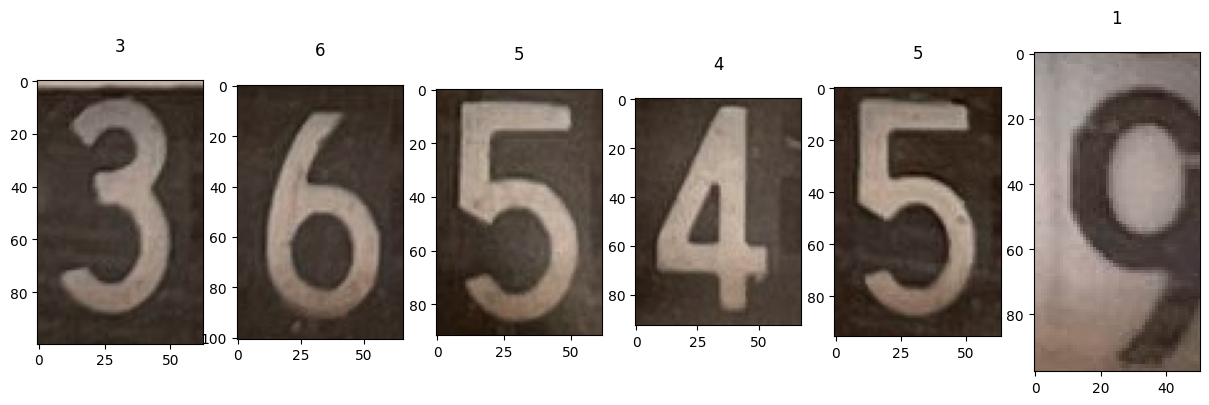

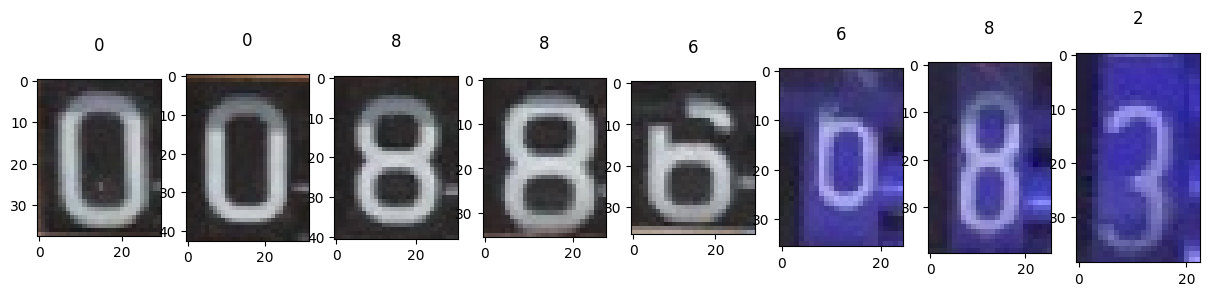

In [1159]:
for z in range(len(file_boxes)):
    boxes = file_boxes[z]
    f, axarr = plt.subplots(1,len(boxes), figsize=(15, 5))
    figsize=(8, 6)
    values = []
    for i in range(len(boxes)):
        x,y,w,h = boxes[i]
        crop_img = crop_imgs_copy[z][y:h, x:w]
        out,out1 = ocr(crop_img)
        values.append(out)
        axarr[i].imshow(crop_img, cmap='gray')
        axarr[i].set_title(out)